# Simulación de Procesos MA(1) y MA(2)

Simulamos procesos de media móvil de orden 1 y 2 con distintos tamaños muestrales: T = 100, 300 y 500.

**MA(1):** $X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1}$

**MA(2):** $X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}$

donde $\varepsilon_t \sim \text{i.i.d. } N(0, 1)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)

# Parámetros
T_values = [100, 300, 500]

# MA(1): theta1 = 0.7
theta1_ma1 = 0.7

# MA(2): theta1 = 0.5, theta2 = -0.3
theta1_ma2 = 0.5
theta2_ma2 = -0.3


def simulate_ma1(T, theta1):
    eps = np.random.normal(0, 1, T + 1)
    return np.array([eps[t] + theta1 * eps[t - 1] for t in range(1, T + 1)])


def simulate_ma2(T, theta1, theta2):
    eps = np.random.normal(0, 1, T + 2)
    return np.array([eps[t] + theta1 * eps[t - 1] + theta2 * eps[t - 2] for t in range(2, T + 2)])


simulations_ma1 = {T: simulate_ma1(T, theta1_ma1) for T in T_values}
simulations_ma2 = {T: simulate_ma2(T, theta1_ma2, theta2_ma2) for T in T_values}

print("Simulaciones generadas correctamente.")

Simulaciones generadas correctamente.


## Trayectorias simuladas — MA(1) con $\theta_1 = 0.7$

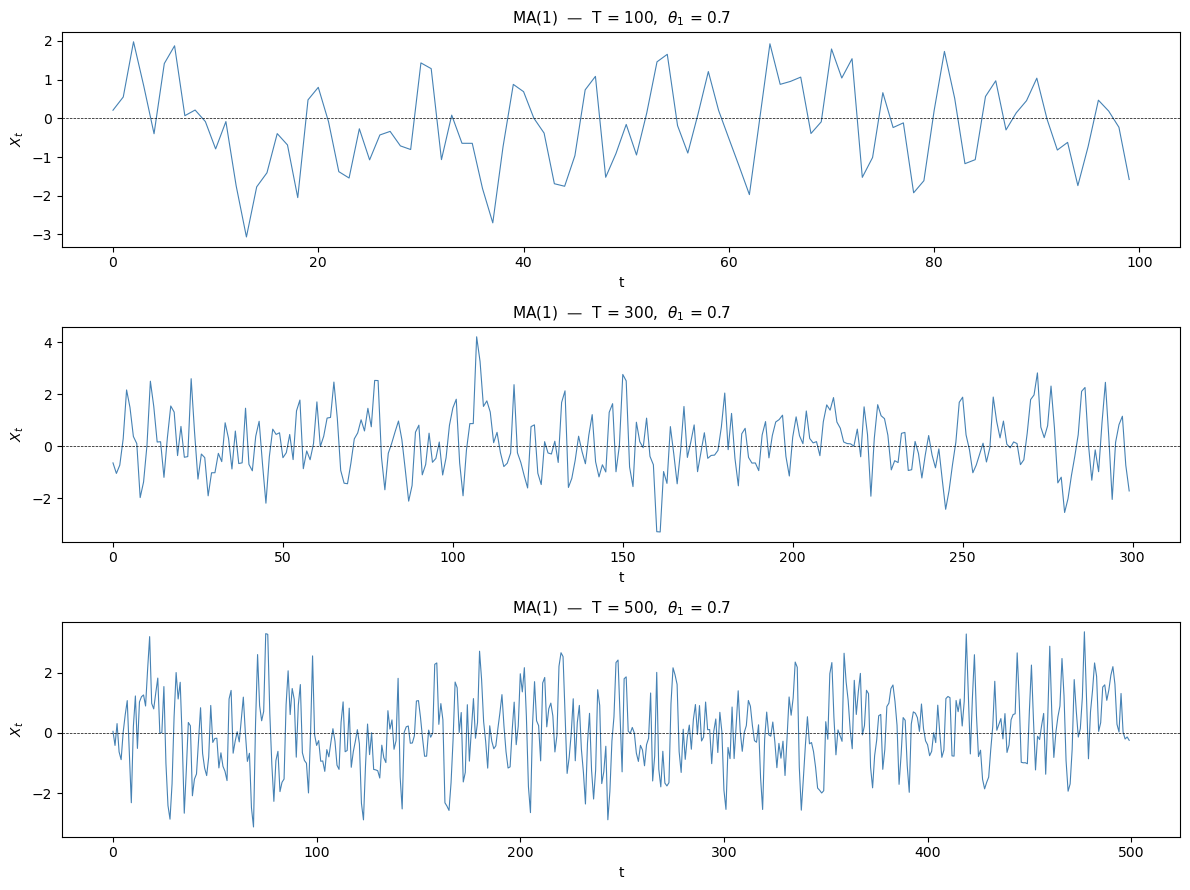

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for ax, T in zip(axes, T_values):
    ax.plot(simulations_ma1[T], linewidth=0.8, color="steelblue")
    ax.set_title(f"MA(1)  —  T = {T},  $\\theta_1$ = {theta1_ma1}", fontsize=11)
    ax.set_xlabel("t")
    ax.set_ylabel("$X_t$")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## Trayectorias simuladas — MA(2) con $\theta_1 = 0.5$, $\theta_2 = -0.3$

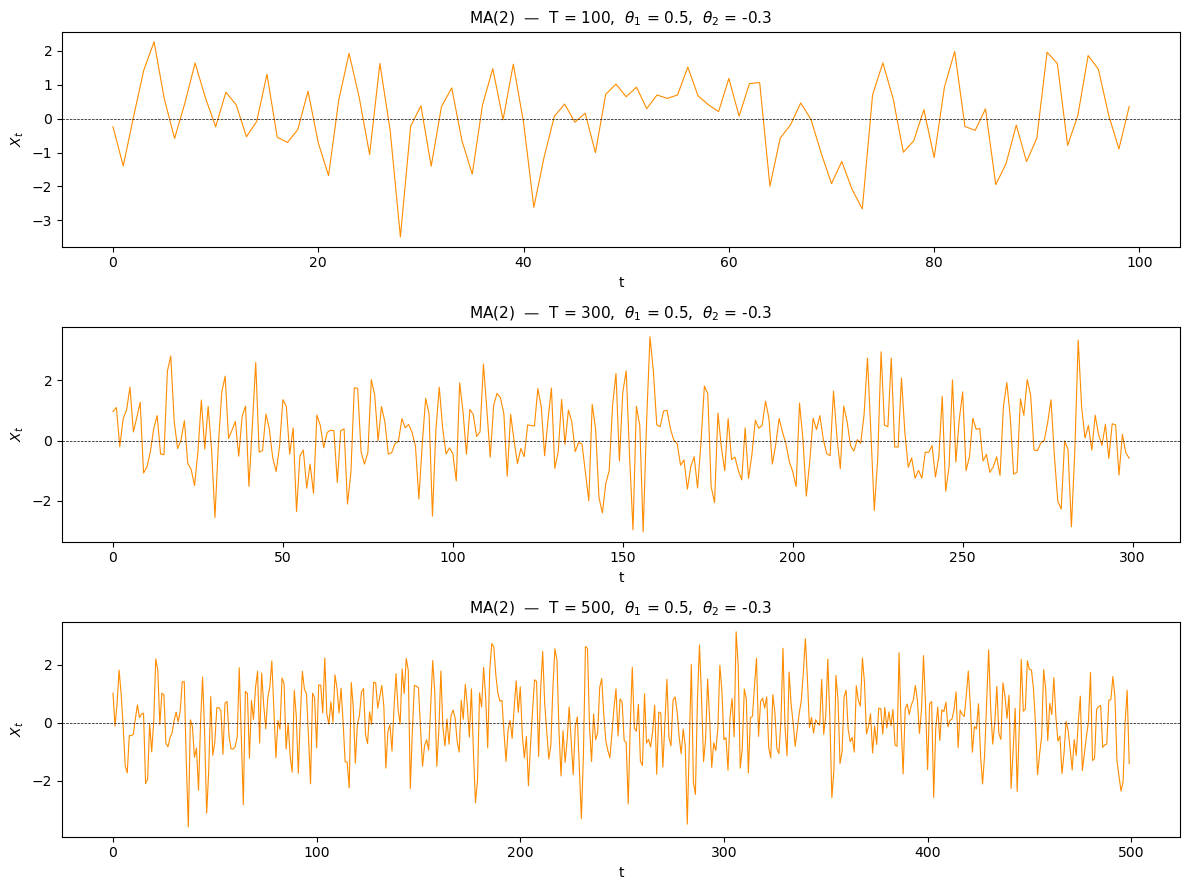

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for ax, T in zip(axes, T_values):
    ax.plot(simulations_ma2[T], linewidth=0.8, color="darkorange")
    ax.set_title(
        f"MA(2)  —  T = {T},  $\\theta_1$ = {theta1_ma2},  $\\theta_2$ = {theta2_ma2}",
        fontsize=11,
    )
    ax.set_xlabel("t")
    ax.set_ylabel("$X_t$")
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

## Función de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)

Para un MA(q) la ACF se corta en el rezago q y la PACF decae de forma gradual — esto es lo que esperamos ver en las gráficas.

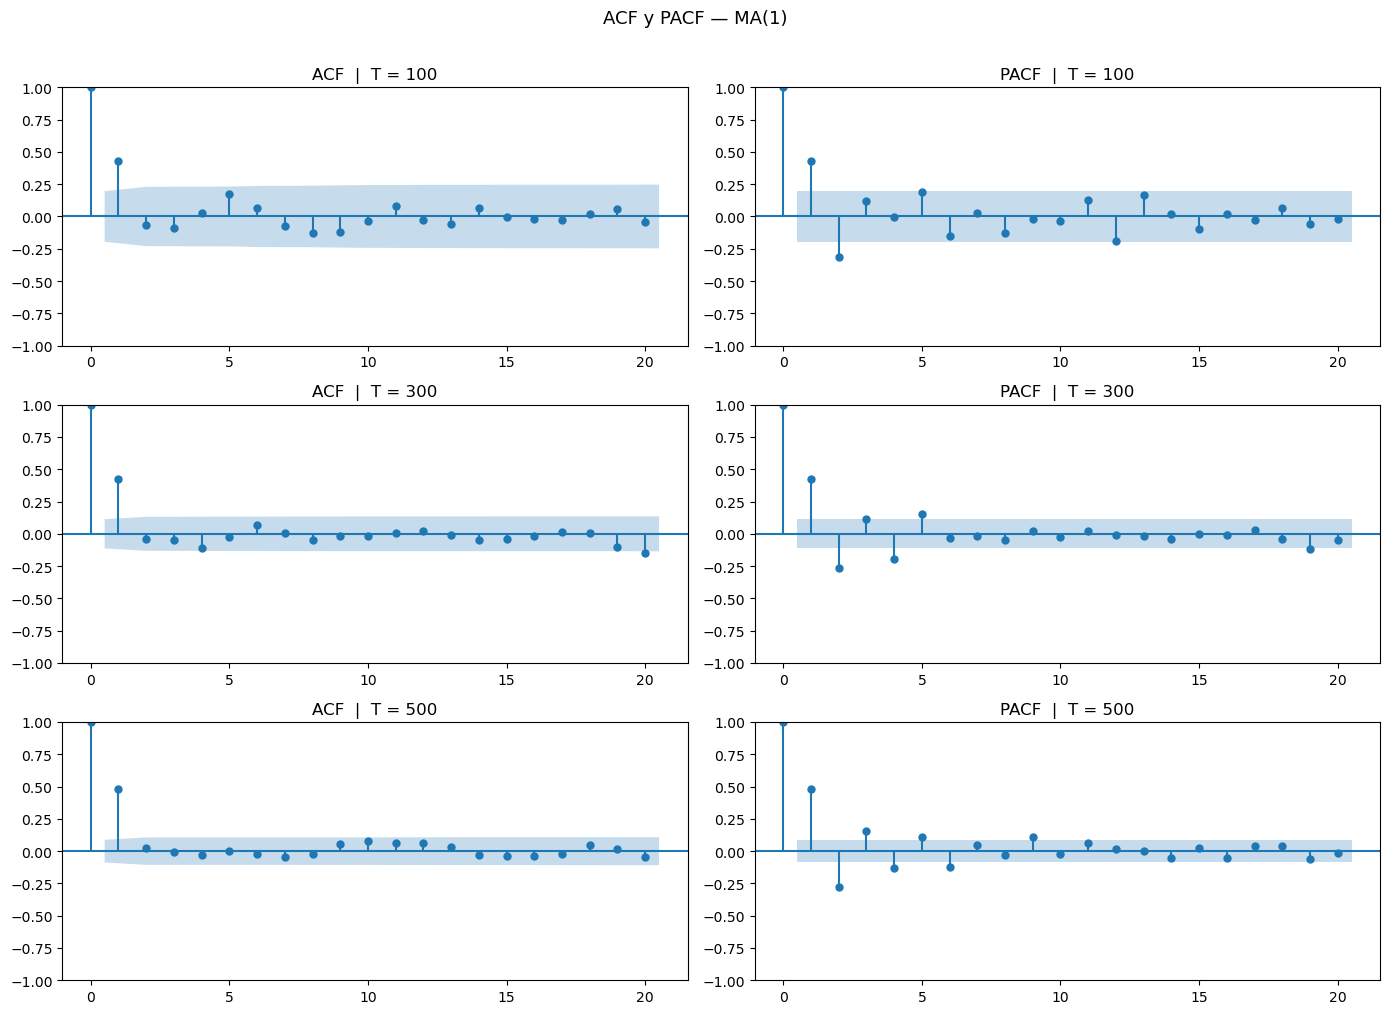

In [4]:
fig, axes = plt.subplots(len(T_values), 2, figsize=(14, 10))
fig.suptitle("ACF y PACF — MA(1)", fontsize=13, y=1.01)

for i, T in enumerate(T_values):
    plot_acf(simulations_ma1[T], lags=20, ax=axes[i, 0], title=f"ACF  |  T = {T}")
    plot_pacf(simulations_ma1[T], lags=20, ax=axes[i, 1], title=f"PACF  |  T = {T}", method="ywm")

plt.tight_layout()
plt.show()

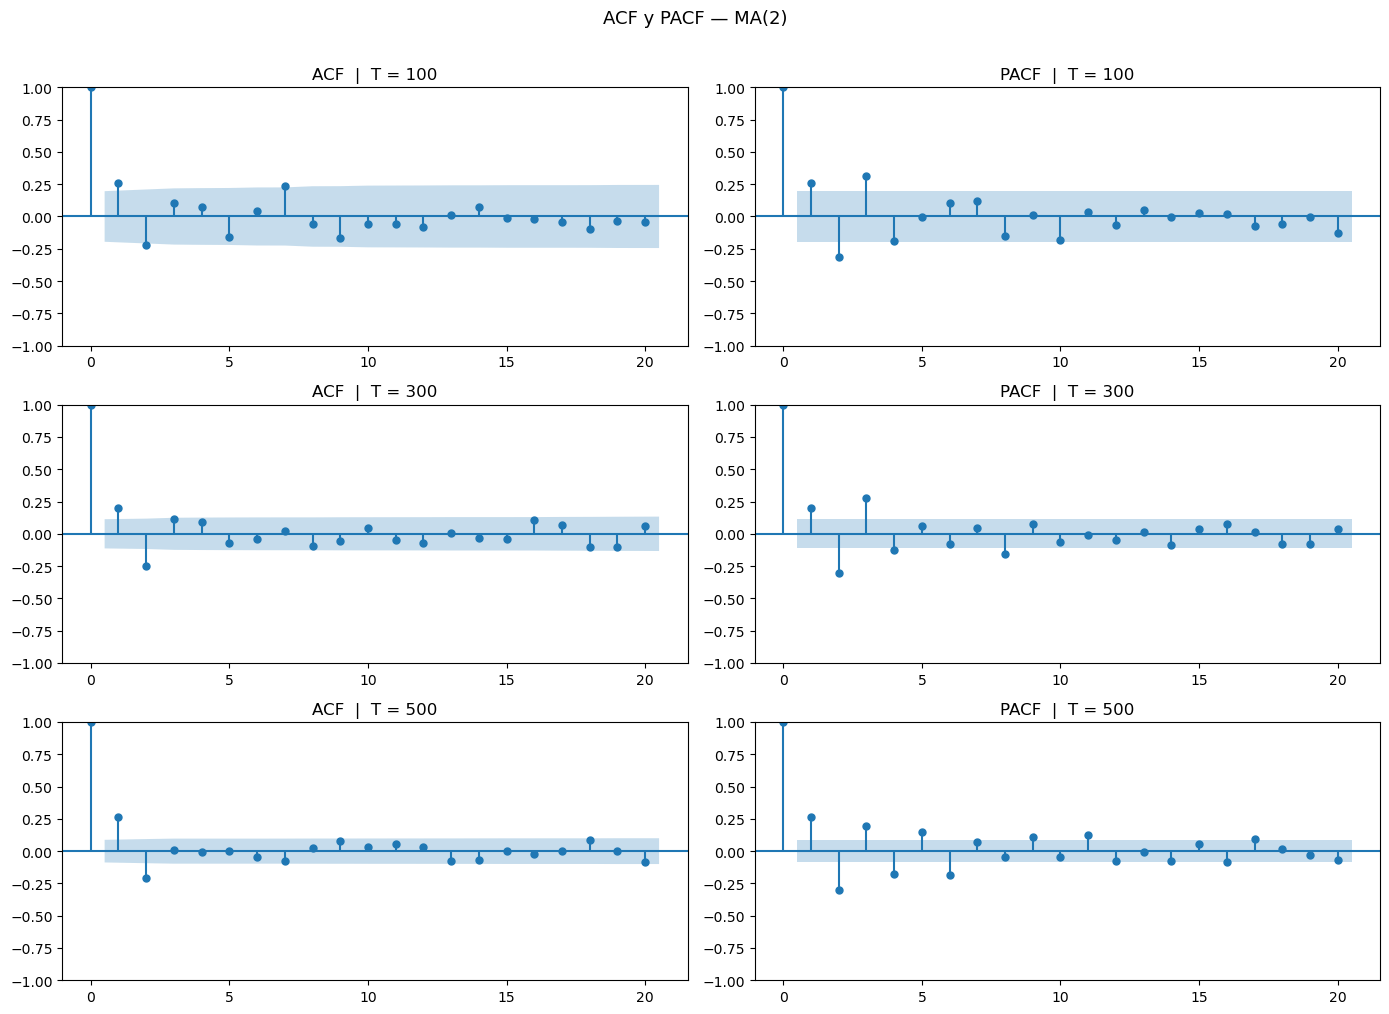

In [5]:
fig, axes = plt.subplots(len(T_values), 2, figsize=(14, 10))
fig.suptitle("ACF y PACF — MA(2)", fontsize=13, y=1.01)

for i, T in enumerate(T_values):
    plot_acf(simulations_ma2[T], lags=20, ax=axes[i, 0], title=f"ACF  |  T = {T}")
    plot_pacf(simulations_ma2[T], lags=20, ax=axes[i, 1], title=f"PACF  |  T = {T}", method="ywm")

plt.tight_layout()
plt.show()

## ACF empírica vs. teórica

**MA(1):** $\rho(1) = \dfrac{\theta_1}{1+\theta_1^2}$, $\quad \rho(k)=0$ para $k>1$

**MA(2):** $\rho(1) = \dfrac{\theta_1(1+\theta_2)}{1+\theta_1^2+\theta_2^2}$, $\quad \rho(2) = \dfrac{\theta_2}{1+\theta_1^2+\theta_2^2}$, $\quad \rho(k)=0$ para $k>2$

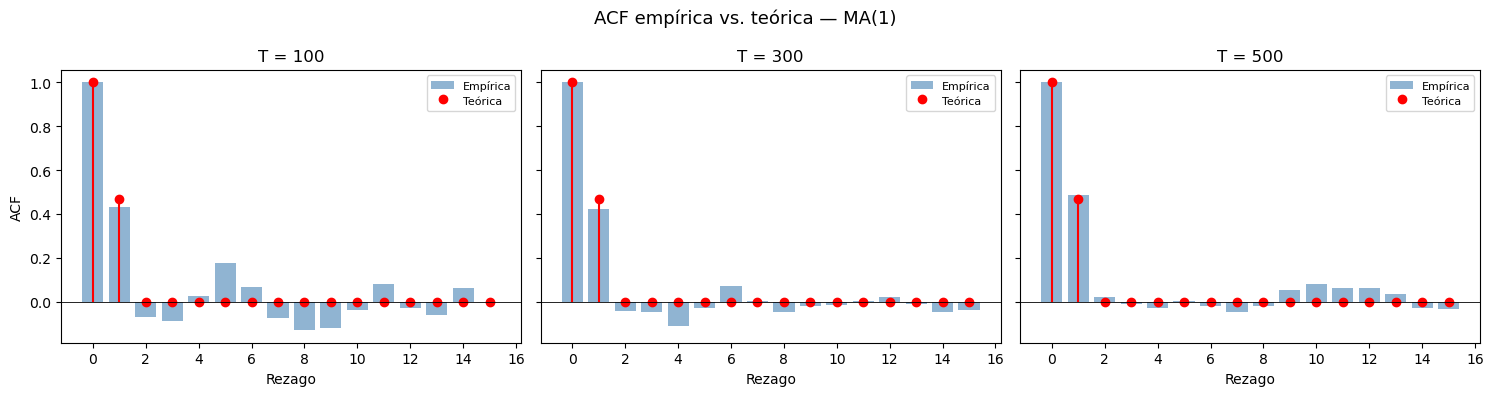

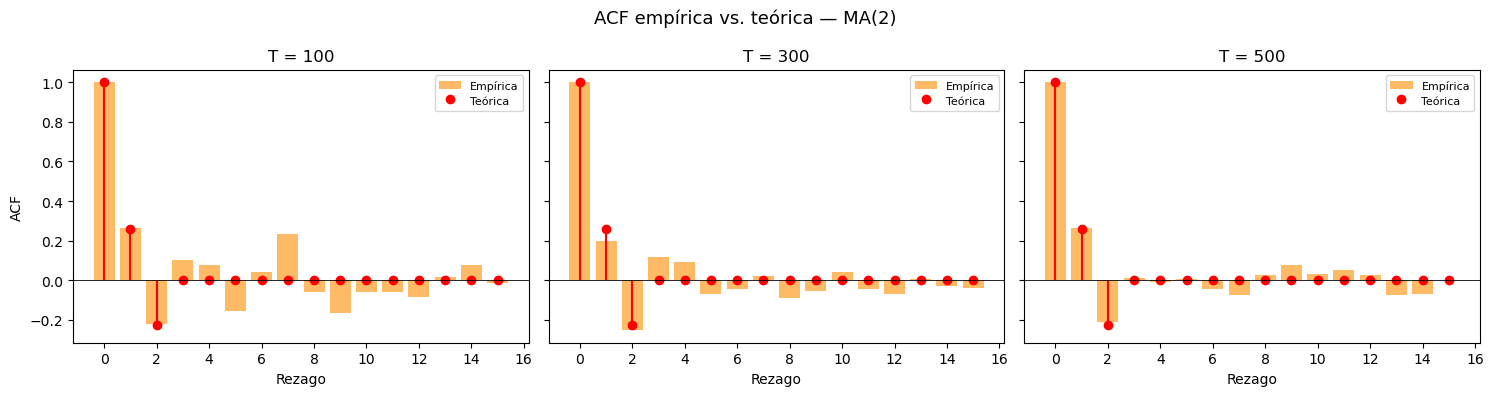

In [6]:
from statsmodels.tsa.stattools import acf

LAGS = 15

# --- ACF teórica MA(1) ---
def theoretical_acf_ma1(theta1, lags):
    rho = np.zeros(lags + 1)
    rho[0] = 1.0
    rho[1] = theta1 / (1 + theta1**2)
    return rho

# --- ACF teórica MA(2) ---
def theoretical_acf_ma2(theta1, theta2, lags):
    denom = 1 + theta1**2 + theta2**2
    rho = np.zeros(lags + 1)
    rho[0] = 1.0
    rho[1] = theta1 * (1 + theta2) / denom
    rho[2] = theta2 / denom
    return rho

lags_idx = np.arange(LAGS + 1)
rho_teorica_ma1 = theoretical_acf_ma1(theta1_ma1, LAGS)
rho_teorica_ma2 = theoretical_acf_ma2(theta1_ma2, theta2_ma2, LAGS)

# ── MA(1) ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(T_values), figsize=(15, 4), sharey=True)
fig.suptitle("ACF empírica vs. teórica — MA(1)", fontsize=13)

for ax, T in zip(axes, T_values):
    rho_emp = acf(simulations_ma1[T], nlags=LAGS, fft=True)

    # Empírica — barras azules
    ax.bar(lags_idx, rho_emp, color="steelblue", alpha=0.6, label="Empírica")
    # Teórica — marcadores rojos
    ax.stem(lags_idx, rho_teorica_ma1, linefmt="r-", markerfmt="ro",
            basefmt=" ", label="Teórica")

    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"T = {T}")
    ax.set_xlabel("Rezago")
    ax.set_ylabel("ACF" if T == T_values[0] else "")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── MA(2) ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(T_values), figsize=(15, 4), sharey=True)
fig.suptitle("ACF empírica vs. teórica — MA(2)", fontsize=13)

for ax, T in zip(axes, T_values):
    rho_emp = acf(simulations_ma2[T], nlags=LAGS, fft=True)

    ax.bar(lags_idx, rho_emp, color="darkorange", alpha=0.6, label="Empírica")
    ax.stem(lags_idx, rho_teorica_ma2, linefmt="r-", markerfmt="ro",
            basefmt=" ", label="Teórica")

    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"T = {T}")
    ax.set_xlabel("Rezago")
    ax.set_ylabel("ACF" if T == T_values[0] else "")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Estadísticas descriptivas

In [ ]:
import pandas as pd

rows = []
for T in T_values:
    for model, series in [("MA(1)", simulations_ma1[T]), ("MA(2)", simulations_ma2[T])]:
        rows.append({
            "Modelo": model,
            "T": T,
            "Media": round(series.mean(), 4),
            "Desv. Est.": round(series.std(), 4),
            "Mín.": round(series.min(), 4),
            "Máx.": round(series.max(), 4),
        })

df_stats = pd.DataFrame(rows).set_index(["Modelo", "T"])
df_stats

# Simulación de Procesos AR(1)

Un proceso AR(1) se define como:

$$X_t = \phi \, X_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \text{i.i.d. } N(0,1), \quad X_0 = 0$$

El comportamiento depende críticamente del valor de $|\phi|$:

| Caso | Condición | Comportamiento |
|------|-----------|----------------|
| Estacionario | $|\phi| < 1$ | Revierte a la media, varianza finita |
| Raíz unitaria | $\phi = 1$ | Caminata aleatoria, varianza $\to \infty$ con $t$ |
| Explosivo | $|\phi| > 1$ | Diverge sin límite |

In [ ]:
phi_values = {
    r"$|\phi| < 1$ — Estacionario ($\phi = 0.7$)": 0.7,
    r"$\phi = 1$ — Raíz unitaria":                  1.0,
    r"$|\phi| > 1$ — Explosivo ($\phi = 1.1$)":     1.1,
}

def simulate_ar1(T, phi):
    eps = np.random.normal(0, 1, T)
    X = np.zeros(T)
    X[0] = eps[0]
    for t in range(1, T):
        X[t] = phi * X[t - 1] + eps[t]
    return X

np.random.seed(42)
simulations_ar1 = {
    label: {T: simulate_ar1(T, phi) for T in T_values}
    for label, phi in phi_values.items()
}

print("Simulaciones AR(1) generadas.")

## Trayectorias simuladas — AR(1)

In [ ]:
colors = ["steelblue", "seagreen", "firebrick"]
labels = list(phi_values.keys())

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Trayectorias AR(1) — filas: caso de φ  |  columnas: T", fontsize=13)

for row, (label, color) in enumerate(zip(labels, colors)):
    for col, T in enumerate(T_values):
        ax = axes[row, col]
        ax.plot(simulations_ar1[label][T], linewidth=0.7, color=color)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        if row == 0:
            ax.set_title(f"T = {T}", fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=8.5)
        ax.set_xlabel("t" if row == 2 else "")

plt.tight_layout()
plt.show()

## ACF empírica vs. teórica — AR(1) estacionario ($\phi = 0.7$)

Para un AR(1) con $|\phi| < 1$ la ACF teórica decae geométricamente:

$$\rho(k) = \phi^k$$

Los casos $\phi = 1$ y $\phi > 1$ no tienen ACF teórica estándar (proceso no estacionario).

In [ ]:
phi_est = 0.7
label_est = labels[0]
LAGS_AR = 20
lags_ar = np.arange(LAGS_AR + 1)
rho_teorica_ar1 = phi_est ** lags_ar

fig, axes = plt.subplots(1, len(T_values), figsize=(15, 4), sharey=True)
fig.suptitle("ACF empírica vs. teórica — AR(1) estacionario ($\\phi = 0.7$)", fontsize=13)

for ax, T in zip(axes, T_values):
    rho_emp = acf(simulations_ar1[label_est][T], nlags=LAGS_AR, fft=True)
    ax.bar(lags_ar, rho_emp, color="steelblue", alpha=0.6, label="Empírica")
    ax.stem(lags_ar, rho_teorica_ar1, linefmt="r-", markerfmt="ro",
            basefmt=" ", label="Teórica $\\phi^k$")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"T = {T}")
    ax.set_xlabel("Rezago")
    ax.set_ylabel("ACF" if T == T_values[0] else "")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()